1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import joblib

2. Load Dataset

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


3. Basic Information

In [3]:
df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

4. Missing Values

In [4]:
df.fillna(method='ffill', inplace=True)

5. Exploratory Data Analysis

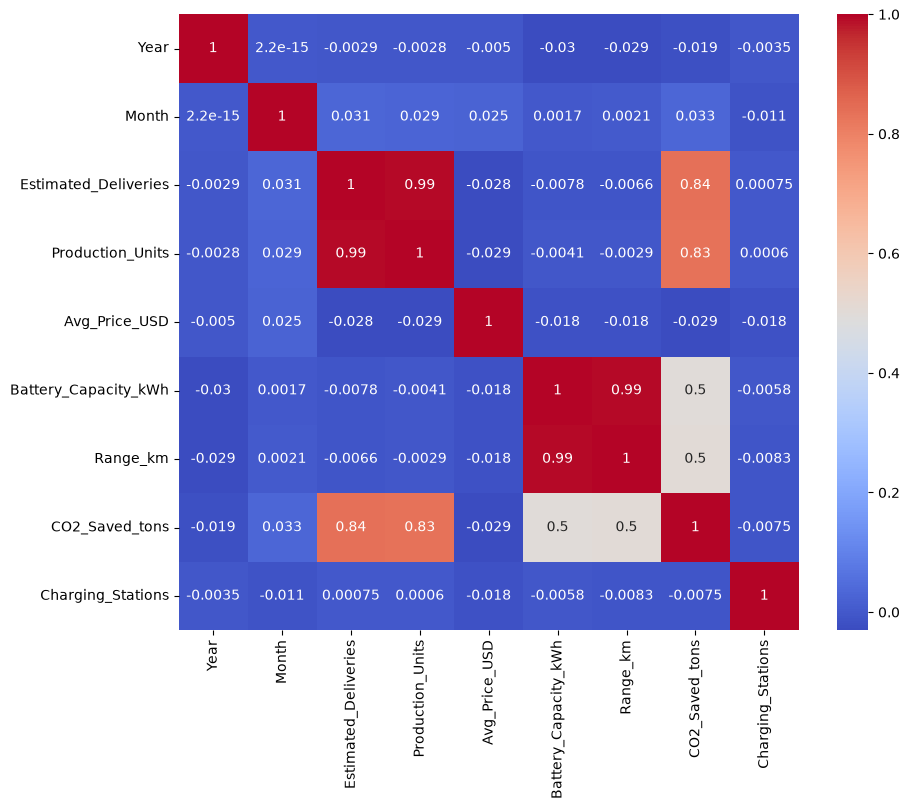

In [5]:
# Correlation Heatmap

plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")

plt.show()

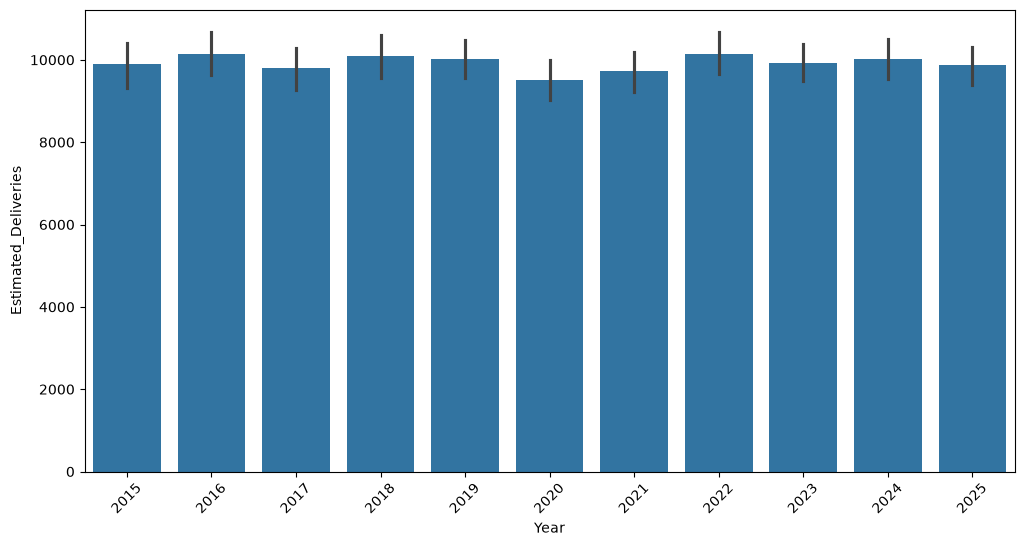

In [6]:
# Deliveries by Year

plt.figure(figsize=(12,6))

sns.barplot(x="Year",
            y="Estimated_Deliveries",
            data=df)

plt.xticks(rotation=45)
plt.show()


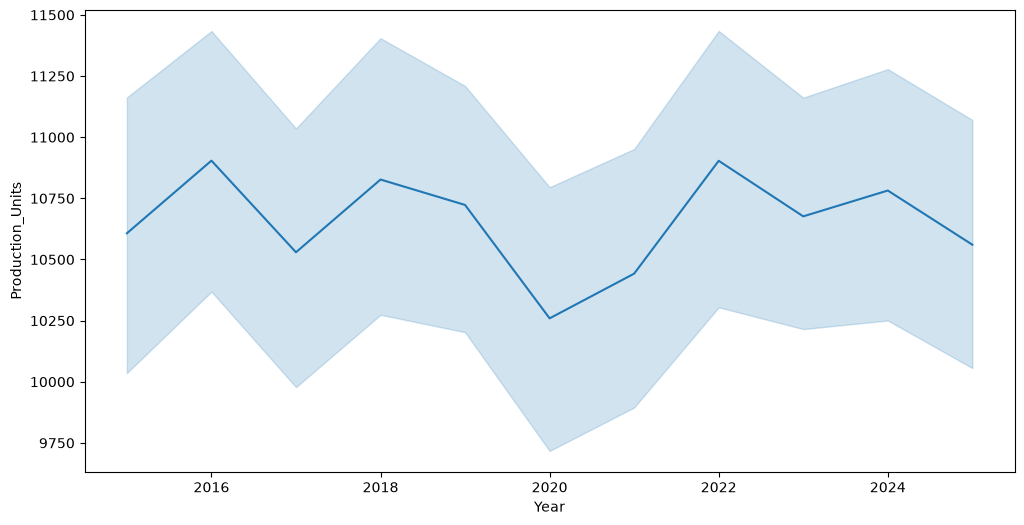

In [7]:
# Production Units

plt.figure(figsize=(12,6))

sns.lineplot(
    x="Year",
    y="Production_Units",
    data=df)

plt.show()


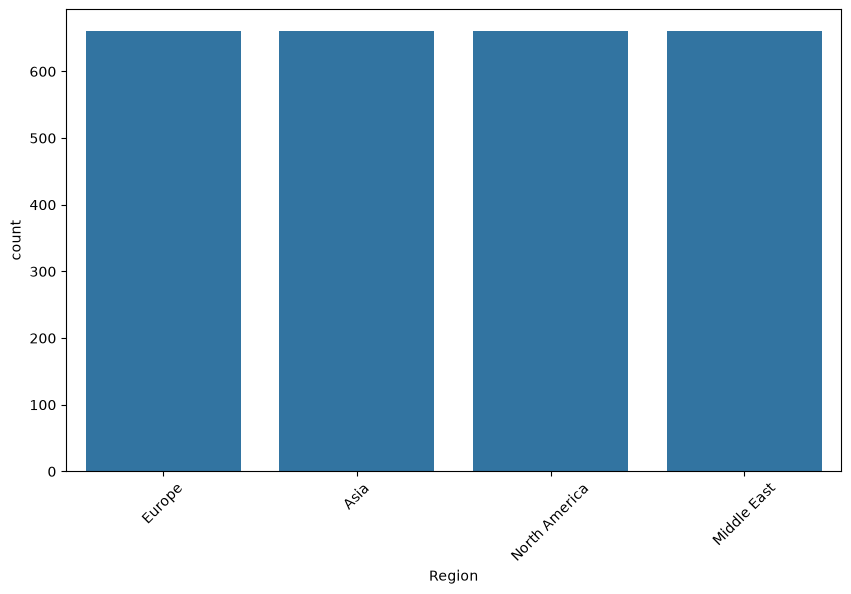

In [8]:
# Region Distribution

plt.figure(figsize=(10,6))

sns.countplot(x="Region", data=df)

plt.xticks(rotation=45)

plt.show()

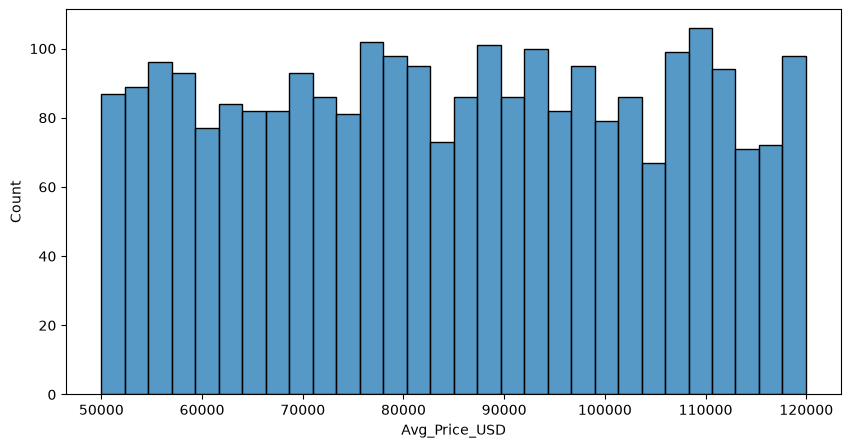

In [9]:
# Average Price Distribution

plt.figure(figsize=(10,5))

sns.histplot(df["Avg_Price_USD"], bins=30)

plt.show()

6. Feature Engineering

In [10]:
# Label Encoding

encoder = LabelEncoder()

categorical = ["Region","Model","Source_Type"]

for col in categorical:
    df[col] = encoder.fit_transform(df[col])

In [11]:
# Features and Target

X = df.drop("Estimated_Deliveries", axis=1)

y = df["Estimated_Deliveries"]

7. Train Test Split

In [12]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

8. Linear Regression

In [13]:
lr = LinearRegression()

lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

In [14]:
# Evaluation

print("Linear Regression")

print("MAE :",mean_absolute_error(y_test,pred_lr))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_lr)))

print("R2 :",r2_score(y_test,pred_lr))

Linear Regression
MAE : 310.1300215468218
RMSE : 383.57656987039127
R2 : 0.9901296027802067


9. Random Forest

In [15]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train,y_train)

pred_rf = rf.predict(X_test)

In [16]:
# Evaluation

print("Random Forest")

print("MAE :",mean_absolute_error(y_test,pred_rf))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_rf)))

print("R2 :",r2_score(y_test,pred_rf))

Random Forest
MAE : 323.46011363636364
RMSE : 409.4960252956731
R2 : 0.9887505867840798


10. Hyperparameter Tuning

In [17]:
params = {

    "n_estimators":[100,200],

    "max_depth":[5,10,20],

    "min_samples_split":[2,5]

}

grid = GridSearchCV(

    RandomForestRegressor(random_state=42),

    params,

    cv=5,

    scoring="r2",

    n_jobs=-1

)

grid.fit(X_train,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [18]:
# Best Parameters

print(grid.best_params_)

{'max_depth': 20, 'min_samples_split': 5, 'n_estimators': 200}


In [19]:
# Best Model

best_rf = grid.best_estimator_

pred = best_rf.predict(X_test)

11. XGBoost

In [20]:
xgb = XGBRegressor(

    objective="reg:squarederror",

    random_state=42

)

xgb.fit(X_train,y_train)

pred_xgb = xgb.predict(X_test)

In [21]:
# Evaluation

print("XGBoost")

print("MAE :",mean_absolute_error(y_test,pred_xgb))

print("RMSE :",np.sqrt(mean_squared_error(y_test,pred_xgb)))

print("R2 :",r2_score(y_test,pred_xgb))


XGBoost
MAE : 233.83799743652344
RMSE : 307.51963860052905
R2 : 0.993655800819397


12. Feature Importance

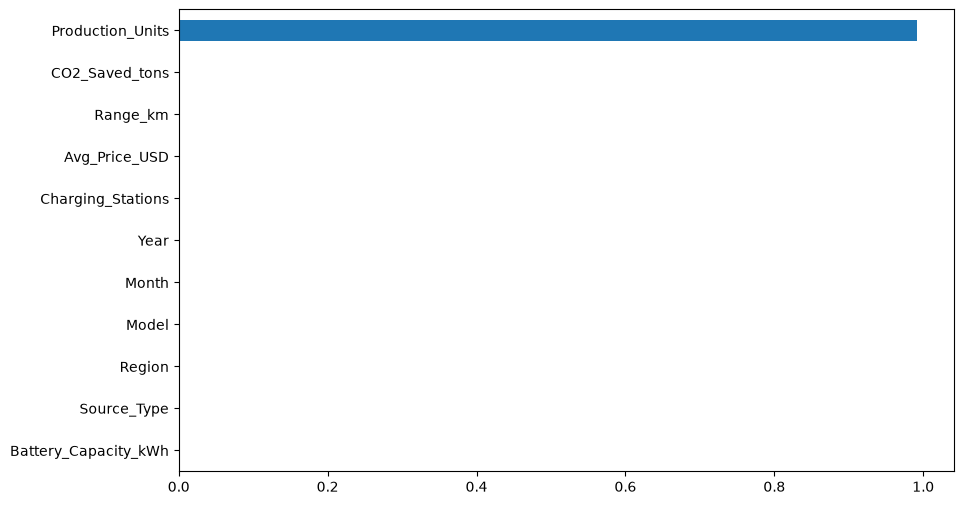

In [22]:
importance = pd.Series(

    best_rf.feature_importances_,

    index=X.columns

)

importance.sort_values().plot(

    kind="barh",

    figsize=(10,6)

)

plt.show()

13. Save Model

In [23]:
joblib.dump(best_rf,"tesla_delivery_model.pkl")

['tesla_delivery_model.pkl']

14. Time Series Forecasting

In [24]:
from statsmodels.tsa.arima.model import ARIMA

In [25]:
# Create Monthly Series

df["Date"] = pd.to_datetime(

    df["Year"].astype(str) + "-" +

    df["Month"].astype(str)

)

series = df.groupby("Date")["Estimated_Deliveries"].sum()

In [26]:
# Train ARIMA

model = ARIMA(series,order=(5,1,0))
result = model.fit()

C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashishjoshi\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [27]:
# Forecast Next 12 Months

forecast = result.forecast(12)

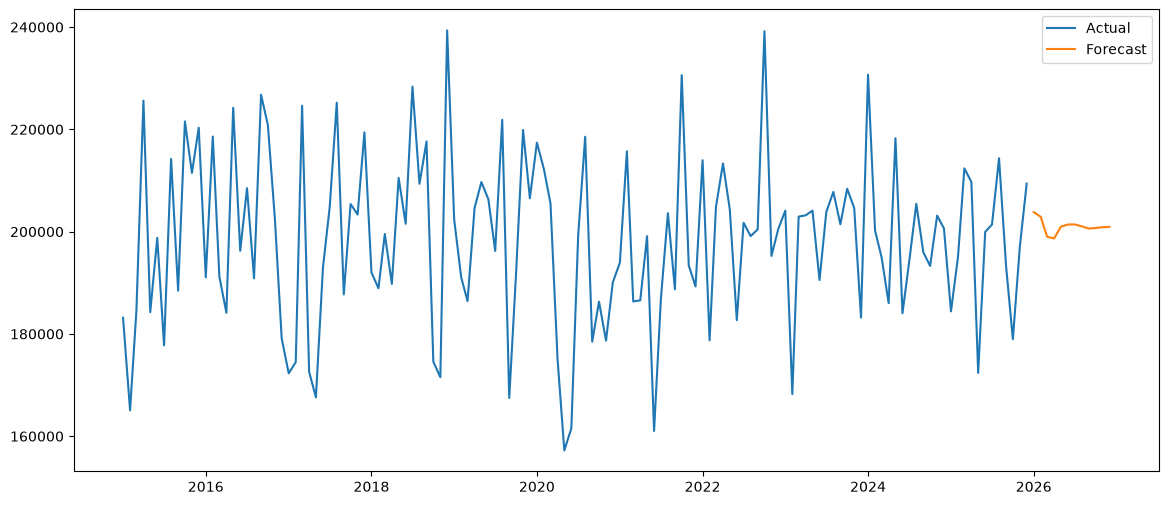

In [28]:
# Plot

plt.figure(figsize=(14,6))

plt.plot(series,label="Actual")

plt.plot(forecast,label="Forecast")

plt.legend()

plt.show()

15. Predict on New Data

In [30]:
sample = X.iloc[[0]]

prediction = best_rf.predict(sample)

print("Predicted :", prediction[0])
print("Actual    :", y.iloc[0])

Predicted : 17199.569623737367
Actual    : 17646
